In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import re
import matplotlib.cm as cm

mac = Path("/Users/aressanuylatorre/")

if (mac / "Desktop/doc/NPG").exists():
    BASE = str(mac / "Desktop/doc/NPG")
    NOU  = f"{BASE}/fitxers"
    ANT  = f"{BASE}/antfiles"
else:
    BASE = "/home/aressanuy/Desktop/doc/NPG/entropianou"
    NOU  = f"{BASE}/nou"
    ANT  = f"{BASE}/antic"

# ==================================================
# PARELLES (T_abans, T_despres, P)
# ==================================================

parelles = {
    1:    (300, 305),
    1000: (310, 315),
    2000: (320, 325),
    3000: (325, 330),
    4000: (330, 335),
    5000: (335, 340),
}

def nou_abans(P):
    t_abans, _ = parelles[P]
    return f"{NOU}/ang_ori_{t_abans}_{P}_2.dat"

def nou_despres(P):
    _, t_despres = parelles[P]
    return f"{NOU}/ang_ori_{t_despres}_{P}_2.dat"

def antic_abans(P):
    t_abans, _ = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_abans}.dat"

def antic_despres(P):
    _, t_despres = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_despres}.dat"

In [3]:
# =========================
# CONSTANTS I CODIS
# =========================
k      = 1.380649e-23
mmol   = 0.10415        # kg/mol
nmol   = 512
NA     = 6.02214076e23
massa  = mmol/ NA   # kg (massa molecula del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360 / bins
    p  = hist * Ap * Ap
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa, p

def entropy_ori(fname, bins=100):
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1, 1, bins + 1),      # bins+1 edges → bins intervals
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    hist, edges = np.histogramdd((th, phi, psi), bins=intervals)

    # Normalitzar explícitament → p suma 1 sempre
    p = hist / hist.sum()

    # Àrea del bin per la correcció d'entropia
    dth  = edges[0][1]  - edges[0][0]
    dphi = edges[1][1]  - edges[1][0]
    dpsi = edges[2][1]  - edges[2][0]
    A = dth * dphi * dpsi

    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
    return S / massa, p

def calcula_entropia(ruta_fitxer, bins):
    intv = bins
    with open(ruta_fitxer, 'r') as fitxer:
        psi, phi = [], []
        for _ in range(4):
            fitxer.readline()

        for _ in range(1001):
            steps = 0
            max_steps = 1001
            while steps < max_steps:
                line = fitxer.readline()
                if not line or '*************' in line:
                    break
                p = line.split()
                if len(p) >= 8:
                    psi.append(float(p[6]))
                    phi.append(float(p[7]))
                steps += 1

    i_psi = np.linspace(-180, 180, intv)
    i_phi = np.linspace(-180, 180, intv)
    hist2d, _, _ = np.histogram2d(psi, phi, bins=[i_psi, i_phi], density=True)

    k = 1.38e-23
    Ap = 360 / intv
    Aa = 360 / intv
    p = hist2d * Ap * Aa 
    pp = Ap * Aa
    sumi = 0
    f, c = p.shape
    for i in range(1, f):
        for j in range(1, c):
            if p[i][j] != 0:
                sumi += p[i][j] * np.log(p[i][j])

    S = -k * sumi + k * np.log(Ap * Aa)
    S = S /massa
    return S,p

def calcula_entropia2(ruta_fitxer, bins):
    intv = bins
    with open(ruta_fitxer, 'r') as fitxer:
        llth, llphi, llpsi = [], [], []
        for _ in range(4):
            fitxer.readline()
        for _ in range(1001):
            steps = 0
            while steps < 1001:
                line = fitxer.readline()
                if not line or '*************' in line:
                    break
                p = line.split()
                if len(p) >= 11:
                    llth.append(float(p[8]))
                    llphi.append(float(p[9]))
                    llpsi.append(float(p[10]))
                steps += 1

    intervals_the = np.linspace(-1,   1,   intv)
    intervals_phi = np.linspace(-180, 180, intv)
    intervals_psi = np.linspace(-180, 180, intv)

    histogram, _ = np.histogramdd((llth, llphi, llpsi),
                                   bins=[intervals_the, intervals_phi, intervals_psi],
                                   density=True)

    Ath = 2   / intv
    Aph = 360 / intv
    Aps = 360 / intv

    
    p = histogram * Ath * Aph * Aps

    sumi = 0
    f, c, a = p.shape
    for i in range(1, f):
        for j in range(1, c):
            for m in range(1, a):
                if p[i][j][m] != 0:
                    sumi += p[i][j][m] * np.log(p[i][j][m])

    S = -k * sumi + k * np.log(Ath * Aph * Aps)
    return S / massa, p

def entropy_ori_nou(fname, bins=20):
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)
    Sthpsi  = S_2d(th, psi, 8, 10)
    Sphipsi = S_2d(phi, psi, 9, 10)
    Sth     = S_1d(th,  8)
    Sphi    = S_1d(phi, 9)
    Spsi    = S_1d(psi, 10)

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    return Stot / massa , p

def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    print(f"N punts: {len(th)}")
    return len(th)

def diagnose_histogram(p, N, label=""):
    total = p.size
    buits = np.sum(p < 1/N)
    print(f"{label}")
    print(f"  Total bins:     {total}")
    print(f"  Bins buits:     {buits}  ({100*buits/total:.1f}%)")
    print(f"  Bins ocupats:   {total - buits}  ({100*(1-buits/total):.1f}%)")
    print(f"  p_max:          {p.max():.4f}")
    print(f"  sum(p):         {p.sum():.4f}")


In [ ]:
def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, bins=b)[0]
        S512b = entropy_fn(file_512_b, bins=b)[0]
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)

    for b, s216, s512 in zip(bins_list, S216, S512):
        print(f"bins={b:3d}  S216={s216:.6e}  S512={s512:.6e} ")
        print(f"{S216b} ")
        print(f"{S216a} ")

    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

def compare_entropy_by_bins2(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=calcula_entropia,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, intv=b)[0]
        S216b = entropy_fn(file_216_b, intv=b)[0]
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, intv=b)[0]
        S512b = entropy_fn(file_512_b, intv=b)[0]
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)


    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

bins_list = np.arange(250, 251, 10)
#bins_list = np.arange(250, 251, 100)
P = 3000
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)
file_512_b = nou_abans(P)
file_512_a = nou_despres(P)
#file_512_b = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_300.dat"
#file_512_a = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_305.dat"

compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_ori2, ylabel=r'$\Delta S_{conf}$ (J / kg K)')


bins_conf=200, bins_ori=20
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
 P (bar)            Sc1           Sc2           ΔSc            So1           So2           ΔSo            ΔSt
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
       1       624.1639      774.6162      150.4523       648.4561      983.2720      334.8158       485.2682
    1000       629.5629      778.9048      149.3419       659.5528      981.5277      321.9749       471.3168
    2000       639.0076      783.8177      144.8101       682.6445      979.7771      297.1326       441.9426
    3000       656.2348      785.2395      129.0047       707.9952      978.2228      270.2276       399.2323
    4000       653.8608      787.6178      133.7570       705.3998      976.3956      270.9958       404.7528
    5000       715.7548      787.2904       71.5356       807.5834      963.7833      156.19

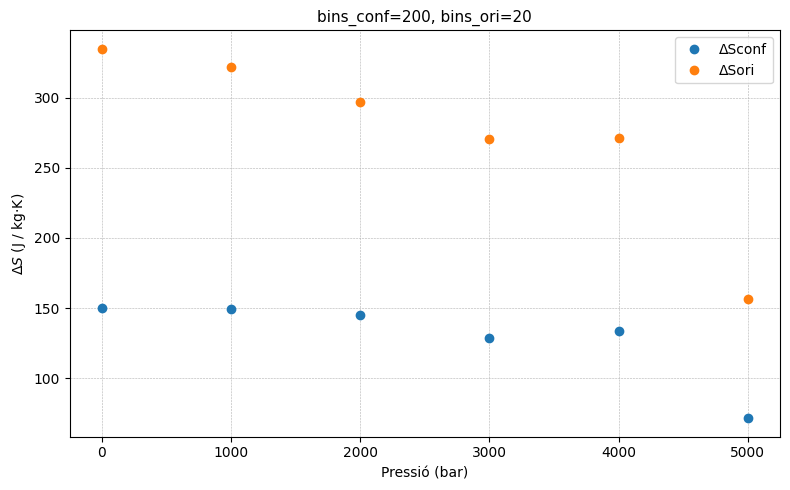

[(1,
  np.float64(624.1638517270851),
  np.float64(774.6161885239673),
  np.float64(150.45233679688215),
  np.float64(648.4561174682555),
  np.float64(983.2719585675501),
  np.float64(334.81584109929463),
  np.float64(485.2681778961768)),
 (1000,
  np.float64(629.5629034251198),
  np.float64(778.9047839467155),
  np.float64(149.34188052159573),
  np.float64(659.5527753306874),
  np.float64(981.5276748093767),
  np.float64(321.9748994786893),
  np.float64(471.316780000285)),
 (2000,
  np.float64(639.0075760501403),
  np.float64(783.8176542781027),
  np.float64(144.81007822796244),
  np.float64(682.6445276983114),
  np.float64(979.7770983278469),
  np.float64(297.1325706295355),
  np.float64(441.94264885749794)),
 (3000,
  np.float64(656.2348250432906),
  np.float64(785.2395226052055),
  np.float64(129.0046975619149),
  np.float64(707.9952200230164),
  np.float64(978.222849383131),
  np.float64(270.22762936011463),
  np.float64(399.23232692202953)),
 (4000,
  np.float64(653.8607608836923

In [36]:
def analitza_entropy(parelles, nou_abans, nou_despres, bins1=200, bins2=50):
    """
    Calcula ΔSconf, ΔSori i ΔStotal per a cada pressió,
    mostra una taula formatada i fa el plot.
    """
    resultats = []

    for P in parelles:
        Sc1 = entropy_conf(nou_abans(P), bins=bins1)[0]
        Sc2 = entropy_conf(nou_despres(P), bins=bins1)[0]
        So1 = entropy_ori(nou_abans(P), bins=bins2)[0]
        So2 = entropy_ori(nou_despres(P), bins=bins2)[0]

        Sc = -Sc1 + Sc2
        So = -So1 + So2
        St = Sc + So

        resultats.append((P, Sc1, Sc2, Sc, So1, So2, So, St))

    # ── Taula ─────────────────────────────────────────────────────────────────
    col = 13
    header = (f"{'P (bar)':>8}  {'Sc1':>{col}} {'Sc2':>{col}} {'ΔSc':>{col}}"
              f"  {'So1':>{col}} {'So2':>{col}} {'ΔSo':>{col}}  {'ΔSt':>{col}}")
    sep = "─" * len(header)
    print(f"\nbins_conf={bins1}, bins_ori={bins2}")
    print(sep)
    print(header)
    print(sep)
    for P, Sc1, Sc2, Sc, So1, So2, So, St in resultats:
        print(f"{P:>8d}  {Sc1:{col}.4f} {Sc2:{col}.4f} {Sc:{col}.4f}"
              f"  {So1:{col}.4f} {So2:{col}.4f} {So:{col}.4f}  {St:{col}.4f}")
    print(sep)
    print("Unitats: J/(kg·K)")

    # ── Plot ──────────────────────────────────────────────────────────────────
    pressions = [r[0] for r in resultats]
    Sc_list   = [r[3] for r in resultats]
    So_list   = [r[6] for r in resultats]
    St_list   = [r[7] for r in resultats]

    plt.figure(figsize=(8, 5))
    plt.title(f"bins_conf={bins1}, bins_ori={bins2}", fontsize=11)
    plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
    plt.plot(pressions, So_list, 'o', label='ΔSori')
    # plt.plot(pressions, St_list, 'o', label='ΔStotal')
    plt.xlabel('Pressió (bar)')
    plt.ylabel(r'$\Delta S$ (J / kg·K)')
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return resultats

analitza_entropy(parelles, nou_abans, nou_despres, bins1=200, bins2=20)

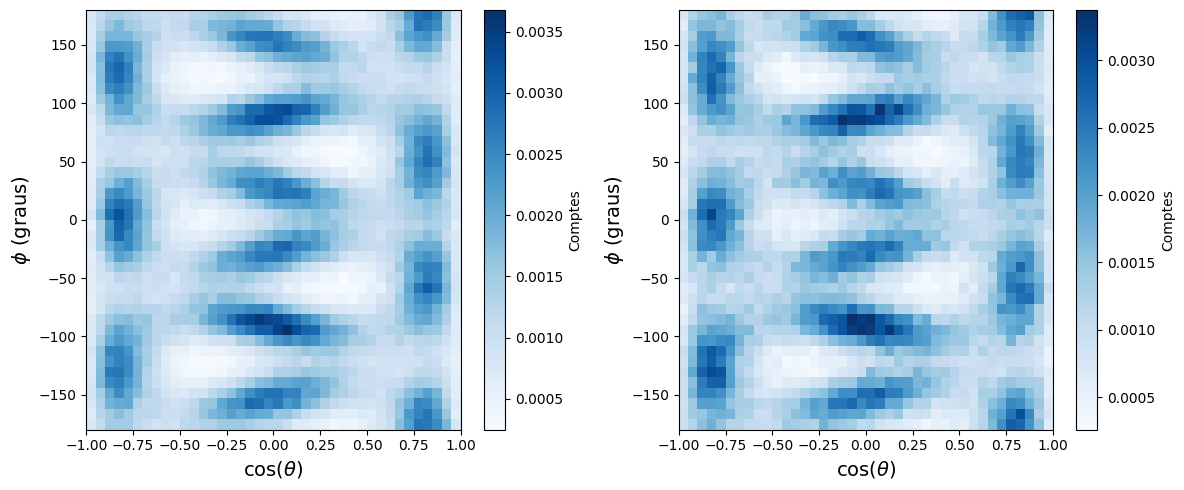

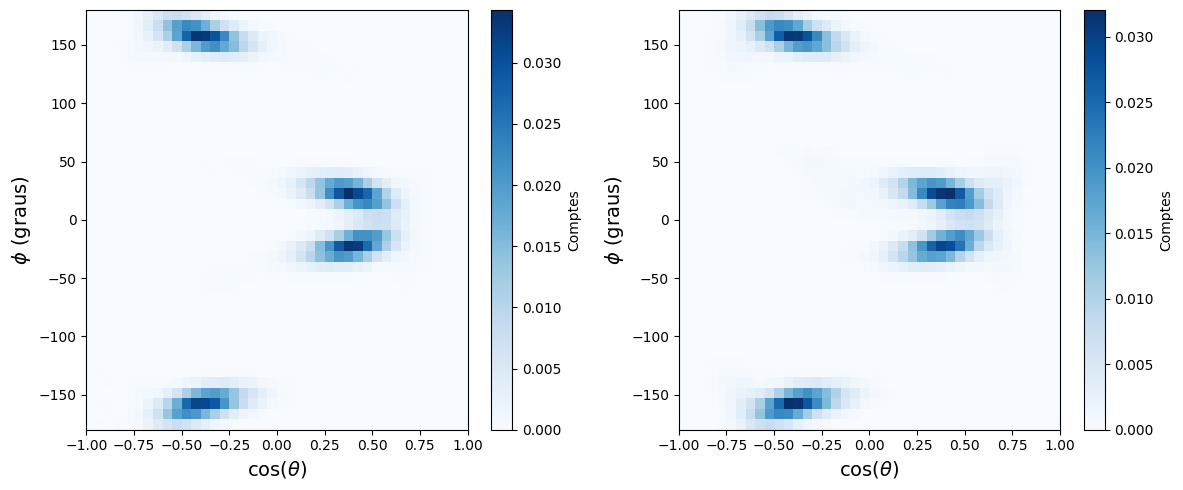

In [16]:
def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
        v = line.split()
        if len(v) >= 10:
            theta.append(float(v[8]))
            phior.append(float(v[10]))
    return np.array(theta), np.array(phior)

def compare_files_2d(file_list,
                     bins=40,
                     theta_range=(-1, 1),
                     phior_range=(-180, 180)):
    #labels = ['216', '512']
    cmaps  = ['Blues', 'Blues']

    fig, axes = plt.subplots(1, len(file_list), figsize=(6 * len(file_list), 5))
    if len(file_list) == 1:
        axes = [axes]

    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)

        hist, xedges, yedges = np.histogram2d(theta, phior, bins=bins,
                                               range=[theta_range, phior_range],density=True)
        mesh = axes[i].pcolormesh(xedges, yedges, hist.T,
                                   cmap=cmaps[i % len(cmaps)])
        #axes[i].set_title(labels[i], fontsize=14)
        axes[i].set_xlabel(r'$\cos(\theta)$', fontsize=14)
        axes[i].set_ylabel(r'$\phi$ (graus)', fontsize=14)
        fig.colorbar(mesh, ax=axes[i], label='Comptes')

    plt.tight_layout()
    #plt.savefig(f"{BASE}/figures/comparativa_2d.png", dpi=150)
    plt.show()


#compare_files_2d([nou_abans(1000),
#antic_abans(1000)
#])



compare_files_2d([nou_despres(1000),
"/home/aressanuy/Desktop/doc/NPG/entropianou/antic/ang_ori_0_305.dat"
])
compare_files_2d([nou_abans(1000),
"/home/aressanuy/Desktop/doc/NPG/entropianou/antic/ang_ori_0_300.dat"
])

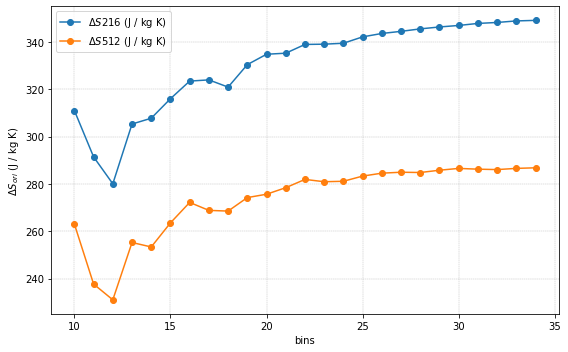

[263.02889461 237.6697502  231.00192643 255.23625199 253.3476469
 263.53302847 272.17505063 268.81580089 268.51714483 274.2237867
 275.64160232 278.40676187 281.90486346 280.92481498 281.1179081
 283.3070437  284.54570549 284.94131939 284.82223004 285.78985818
 286.55857983 286.23498987 286.05933686 286.56724424 286.81496147] [311.02090606 291.43055217 280.04809209 305.32168159 307.77131242
 316.01675269 323.46797003 323.97628659 320.92709946 330.4272572
 334.8158411  335.26233508 338.96285151 339.07195997 339.47089188
 342.15920669 343.60028566 344.49940232 345.53859883 346.34773051
 346.98870322 347.84434169 348.25495206 348.90678862 349.13702119]


In [ ]:
def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    llS512a,llS512b = [], []
    diff = []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]   
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, bins=b)[0]
        llS512a.append(S512a)
        S512b = entropy_fn(file_512_b, bins=b)[0]
        llS512b.append(S512b)
        S512.append(S512a - S512b)
        diff.append(S512a - S216a)


    S216, S512 = np.array(S216), np.array(S512)


    #for b, s216, s512 in zip(bins_list, S216, S512):
    #    print(f"bins={b:3d}  S216={s216:.6e}  S512={s512:.6e} ")
    #    print(f"{S216b} ")
    #    print(f"{S216a} ")

    plt.figure(figsize=(8, 5))
    #plt.plot(bins_list, llS512a, '-o', label='300')
    plt.plot(bins_list, S216, '-o', label=r'$\Delta S 216$ (J / kg K)')
    plt.plot(bins_list, S512, '-o', label=r'$\Delta S 512$ (J / kg K)')
    #plt.plot(bins_list, diff, '-o', label=r'$\Delta S_{512} - \Delta S_{216}$ (J / kg K)')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S512, S216

def compare_entropy_by_bins2(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=calcula_entropia,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, intv=b)
        S216b = entropy_fn(file_216_b, intv=b)
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, intv=b)
        S512b = entropy_fn(file_512_b, intv=b)
        S512.append(S512a - S512b)

    S216, S512 = np.array(S216), np.array(S512)

    
    plt.figure(figsize=(8, 5))
    plt.plot(bins_list, S216, '-o', label='216')
    plt.plot(bins_list, S512, '-o', label='512')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216, S512

bins_list = np.arange(10, 35, 1)
#bins_list = np.arange(350, 351, 100)

P = 1
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)
file_512_b = antic_abans(P)
file_512_a = antic_despres(P)
#file_512_b = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_300.dat"
#file_512_a = "/home/aressanuy/Desktop/doc/NPG/entropianou/ang_fix_NPG_305.dat"
 

# Amb entropy_conf 
S216, S512 = compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_ori, ylabel=r'$\Delta S_{ori}$ (J / kg K)')
#print(S216,S512)

N punts: 512000


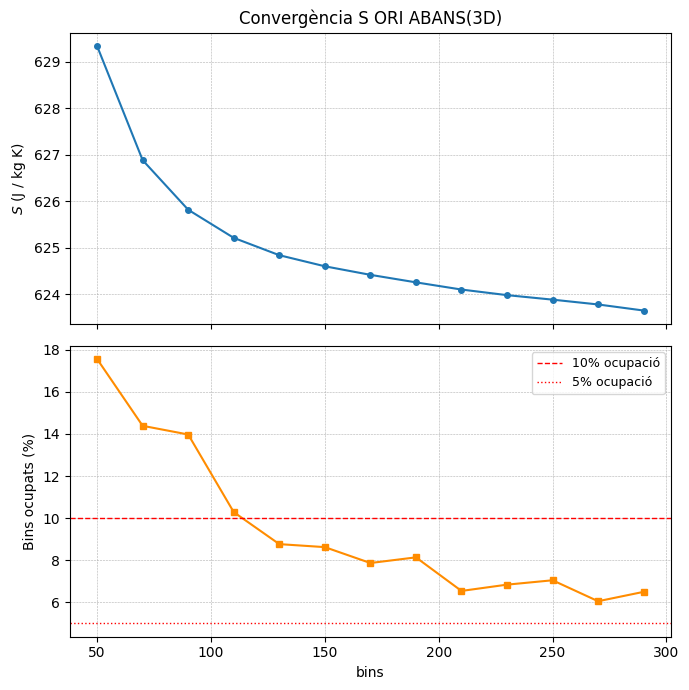

N punts: 512000


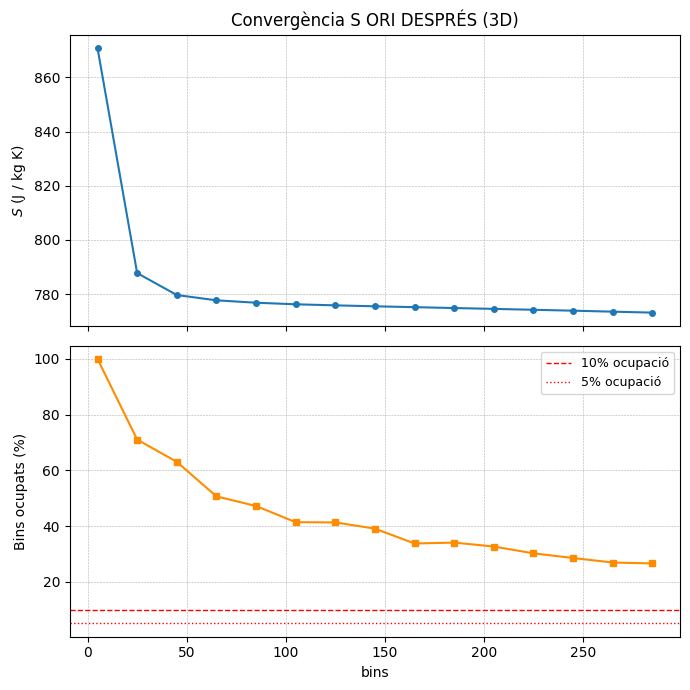

In [ ]:
def convergence_plot(fname, entropy_fn, bins_list, label=""):
    S_list = []
    occ_list = []
    N = count_points(fname)
    
    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        S_list.append(S)
        occ_list.append(100 * np.sum(p >= 1/N) / p.size)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    
    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)
    
    ax2.plot(bins_list, occ_list, '-s', ms=4, color='darkorange')
    ax2.axhline(10, color='red', lw=1, ls='--', label='10% ocupació')
    ax2.axhline(5,  color='red', lw=1, ls=':',  label='5% ocupació')
    ax2.set_ylabel('Bins ocupats (%)')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)
    
    plt.tight_layout()
    plt.show()
    
    return np.array(S_list), np.array(occ_list)


# Per conf (2D) — rang gran
S_conf, occ_conf = convergence_plot(
    nou_abans(1), entropy_conf,
    bins_list=np.arange(50, 300, 20),
    label="Convergència S CONF ABANS(3D)"
)

# Per ori (3D) — rang petit!
S_ori, occ_ori = convergence_plot(
    nou_despres(1), entropy_conf,
    bins_list=np.arange(5, 300, 20),
    label="Convergència S CONF DESPRÉS (3D)"
)



N punts: 512000


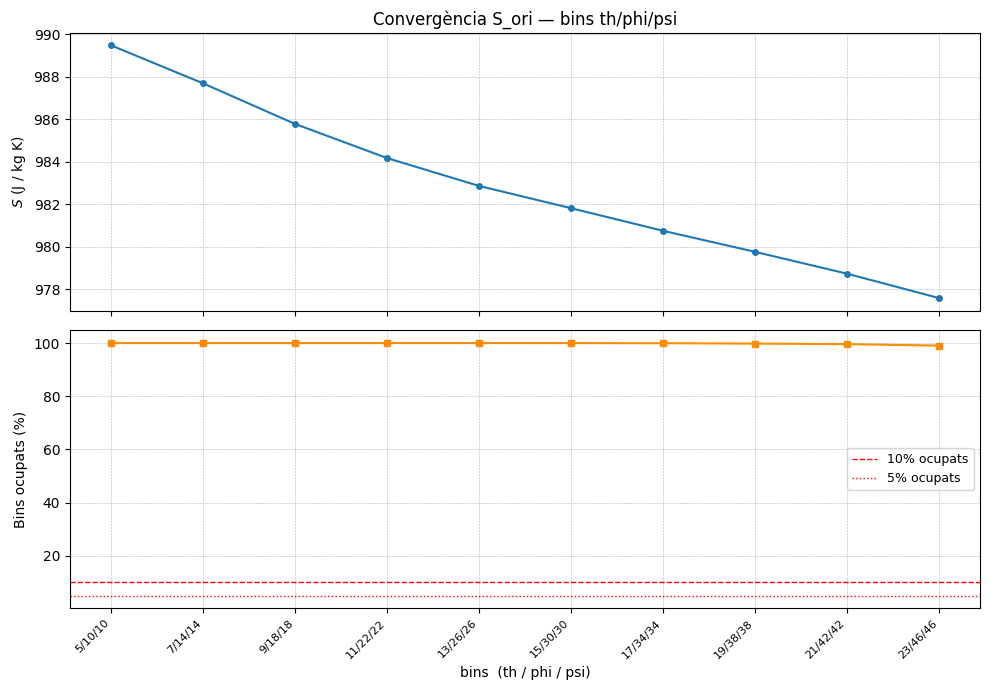

In [350]:
def convergence_plot_ori3(fname, bins_th_list, bins_phi_list, bins_psi_list, label=""):
    """
    bins_th_list, bins_phi_list, bins_psi_list : llistes de la mateixa longitud
    """
    assert len(bins_th_list) == len(bins_phi_list) == len(bins_psi_list), \
        "Les tres llistes han de tenir la mateixa longitud"

    S_list   = []
    occ_list = []
    N = count_points(fname)

    for bth, bphi, bpsi in zip(bins_th_list, bins_phi_list, bins_psi_list):
        S, p = entropy_ori2(fname, bins_th=bth, bins_phi=bphi, bins_psi=bpsi)
        S_list.append(S)
        occ_list.append(100 * np.sum(p >= 1/N) / p.size)

    x = range(len(bins_th_list))
    xlabels = [f"{bth}/{bphi}/{bpsi}" for bth, bphi, bpsi in 
               zip(bins_th_list, bins_phi_list, bins_psi_list)]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(x, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)

    ax2.plot(x, occ_list, '-s', ms=4, color='darkorange')
    ax2.axhline(10, color='red', lw=1, ls='--', label='10% ocupats')
    ax2.axhline(5,  color='red', lw=1, ls=':',  label='5% ocupats')
    ax2.set_ylabel('Bins ocupats (%)')
    ax2.set_xlabel('bins  (th / phi / psi)')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)

    plt.tight_layout()
    plt.show()

    return np.array(S_list), np.array(occ_list)

bins_th  = np.arange(5, 25, 2)           # rang petit [-1, 1]
bins_phi = np.arange(10, 50, 4)          # rang gran [-180, 180]o (2
bins_psi = np.arange(10, 50, 4)          # rang gran [-180, 180]

S_ori, occ_ori = convergence_plot_ori3(
    nou_despres(1),
    bins_th_list=bins_th,
    bins_phi_list=bins_phi,
    bins_psi_list=bins_psi,
    label="Convergència S_ori — bins th/phi/psi"
)

# Entropy ORI with SUM

N punts: 512000


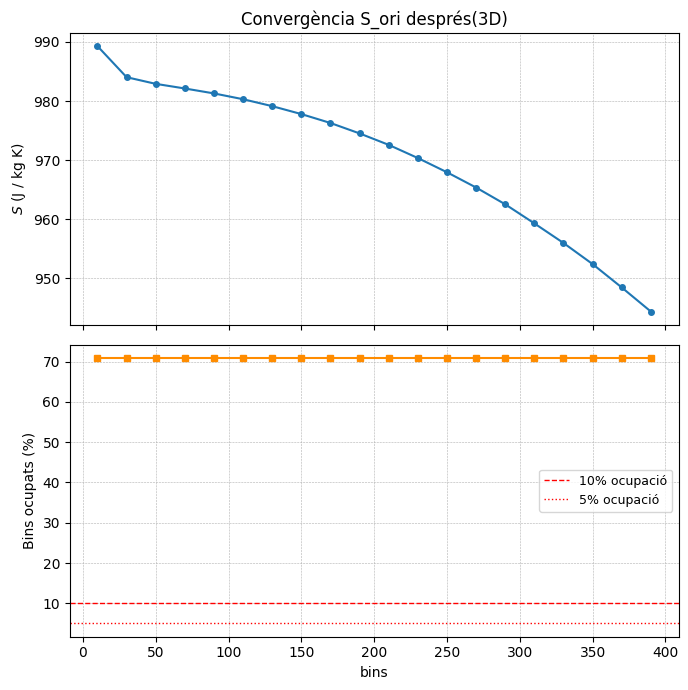

N punts: 512000


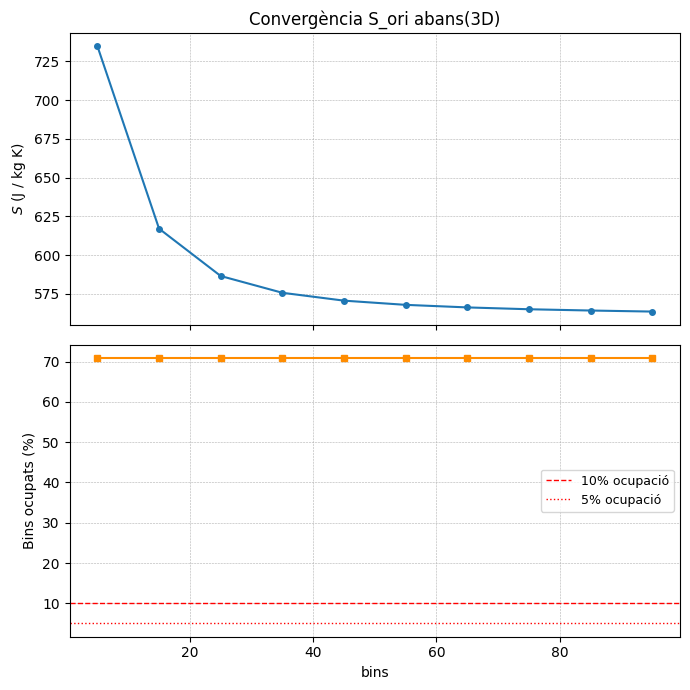

452.3711132633076


In [307]:
# Per conf (2D) — rang gran
S_conf, occ_conf = convergence_plot(
    nou_despres(1), entropy_ori_nou,
    bins_list=np.arange(10, 400, 20),
    label="Convergència S_ori després(3D)"
)

# Per ori (3D) — rang petit!
S_ori, occ_ori = convergence_plot(
    nou_abans(1), entropy_ori_nou,
    bins_list=np.arange(5, 100, 10),
    label="Convergència S_ori abans(3D)"
)

S1 = entropy_ori_nou(nou_abans(1), bins=1000)[0]
S2 = entropy_ori_nou(nou_despres(1), bins=200)[0]
print(S2-S1)

In [ ]:
def entropy_ori_nou_plot(fname, bins=20):
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)  / massa
    Sthpsi  = S_2d(th, psi, 8, 10) / massa
    Sphipsi = S_2d(phi, psi, 9, 10)/ massa
    Sth     = S_1d(th,  8)         / massa
    Sphi    = S_1d(phi, 9)         / massa
    Spsi    = S_1d(psi, 10)        / massa

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    print(f"bins={bins:3d}  Stot={Stot:.6e}  Sth-phi={Sthphi:.6e}  Sth-psi={Sthpsi:.6e}  Sphi-psi={Sphipsi:.6e}  Sth={Sth:.6e}  Sphi={Sphi:.6e}  Spsi={Spsi:.6e}")
    return Stot, Sthphi, Sthpsi, Sphipsi, Sth, Sphi, Spsi


def convergence_plot_ori_nou(fname, bins_list, label=""):

    keys   = ['Stot', 'Sth-phi', 'Sth-psi', 'Sphi-psi', 'Sth', 'Sphi', 'Spsi']
    styles = [
        dict(color='black',      lw=2,   ls='-',  ms=5),   # Stot
        dict(color='steelblue',  lw=1.2, ls='--', ms=3),   # Sth-phi
        dict(color='darkorange', lw=1.2, ls='--', ms=3),   # Sth-psi
        dict(color='seagreen',   lw=1.2, ls='--', ms=3),   # Sphi-psi
        dict(color='steelblue',  lw=1,   ls=':',  ms=3),   # Sth
        dict(color='darkorange', lw=1,   ls=':',  ms=3),   # Sphi
        dict(color='seagreen',   lw=1,   ls=':',  ms=3),   # Spsi
    ]

    results = {k: [] for k in keys}

    for b in bins_list:
        vals = entropy_ori_nou_plot(fname, bins=b)
        for k, v in zip(keys, vals):
            results[k].append(v)

    fig, ax = plt.subplots(figsize=(9, 5))

    for k, st in zip(keys, styles):
        ax.plot(bins_list, results[k], '-o', label=k,
                color=st['color'], lw=st['lw'], ls=st['ls'], ms=st['ms'])

    ax.set_xlabel('bins')
    ax.set_ylabel(r'$S$ (J / kg K)')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return {k: np.array(v) for k, v in results.items()}
llp = [1]
for P in llp:
    results = convergence_plot_ori_nou(
        nou_abans(P),
        bins_list=np.arange(10, 200, 20),
        label="Convergència S_ori_nou —Abans"
    )
    results = convergence_plot_ori_nou(
        nou_despres(P),
        bins_list=np.arange(10, 200, 20),
        label="Convergència S_ori_nou —Després"
)

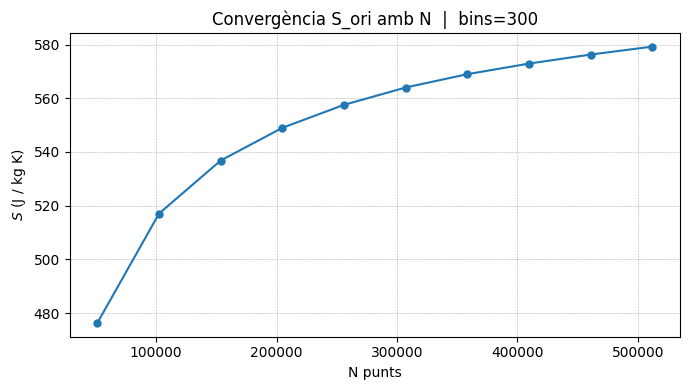

In [327]:
def convergence_plot_N(fname, bins, fractions, label=""):
    """
    Calcula S amb fraccions creixents del dataset per veure si converge amb N.
    fractions : ex [0.2, 0.4, 0.6, 0.8, 1.0]
    """
    # Llegir totes les dades
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    th, phi, psi = np.array(th), np.array(phi), np.array(psi)
    N_total = len(th)

    intervals = [
        np.linspace(-1,   1,   bins + 1),
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    S_list, N_list = [], []
    for frac in fractions:
        N = int(N_total * frac)
        hist, edges = np.histogramdd((th[:N], phi[:N], psi[:N]), bins=intervals)
        p = hist / hist.sum()
        dth  = edges[0][1] - edges[0][0]
        dphi = edges[1][1] - edges[1][0]
        dpsi = edges[2][1] - edges[2][0]
        A = dth * dphi * dpsi
        S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
        S_list.append(S / massa)
        N_list.append(N)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(N_list, S_list, '-o', ms=5)
    ax.set_xlabel('N punts')
    ax.set_ylabel(r'$S$ (J / kg K)')
    ax.set_title(f"{label}  |  bins={bins}")
    ax.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return np.array(N_list), np.array(S_list)

N_list, S_list = convergence_plot_N(
    nou_abans(1),
    bins=300,
    fractions=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    label="Convergència S_ori amb N"
)


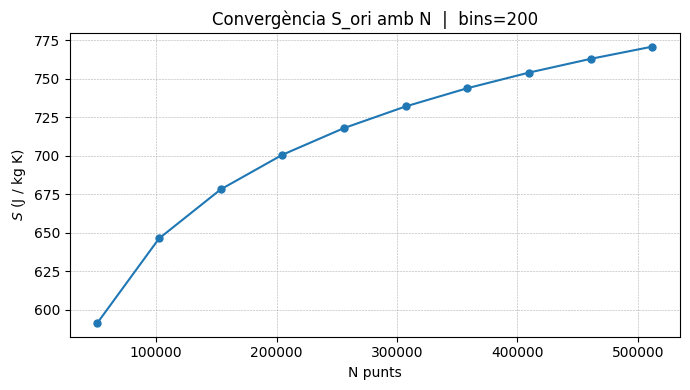

S extrapolada N→∞: 842.61 J/kg K


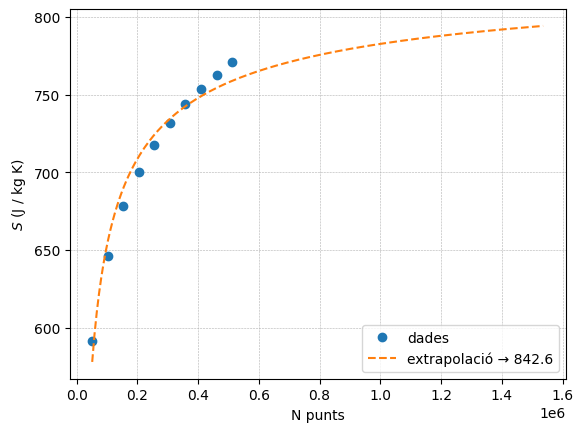

In [341]:
from scipy.optimize import curve_fit

N_list, S_list = convergence_plot_N(
    nou_despres(1),
    bins=200,
    fractions=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    label="Convergència S_ori amb N"
)

def model(N, S_inf, a):
    return S_inf - a / np.sqrt(N)   # comportament típic del biaix

popt, _ = curve_fit(model, N_list, S_list)
S_infinit = popt[0]
print(f"S extrapolada N→∞: {S_infinit:.2f} J/kg K")

# Plot
N_extrap = np.linspace(N_list[0], N_list[-1]*3, 200)
plt.plot(N_list, S_list, 'o', label='dades')
plt.plot(N_extrap, model(N_extrap, *popt), '--', label=f'extrapolació → {S_infinit:.1f}')
plt.xlabel('N punts')
plt.ylabel(r'$S$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.show()

In [7]:
def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    return len(th)


def diagnose_histogram_counts(fname, bins, entropy_fn=entropy_ori, label=""):
    S, p = entropy_fn(fname, bins=bins)
    
    # Reconstruir counts (p normalitzada → multipliquem per N)
    N = count_points(fname)
    counts = p * N  # counts aproximats per bin
    
    ocupats = counts[counts > 0]
    
    mean_counts  = ocupats.mean()
    median_counts = np.median(ocupats)
    below_thresh  = np.sum(ocupats < 7)
    pct_below     = 100 * below_thresh / len(ocupats)
    return mean_counts, median_counts


def convergence_plot_counts(fname, bins_list, entropy_fn=entropy_ori, 
                             threshold=7, label=""):
    N = count_points(fname)
    S_list, mean_list, median_list, pct_below_list = [], [], [], []

    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        counts = p * N

        ocupats = counts[counts > 0]
        mean_c   = ocupats.mean()
        median_c = np.median(ocupats)
        pct_below = 100 * np.sum(ocupats < threshold) / len(ocupats)

        S_list.append(S)
        mean_list.append(mean_c)
        median_list.append(median_c)
        pct_below_list.append(pct_below)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)

    ax2.plot(bins_list, mean_list,   '-o', ms=4, color='steelblue',  label='mitjana counts/bin')
    ax2.plot(bins_list, median_list, '-s', ms=4, color='darkorange', label='mediana counts/bin')
    ax2.axhline(threshold, color='red', lw=1.2, ls='--', 
                label=f'llindar {threshold} counts')
    ax2.set_ylabel('Counts per bin ocupat')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)

    plt.tight_layout()
    plt.show()

    return (np.array(S_list), np.array(mean_list), 
            np.array(median_list), np.array(pct_below_list))

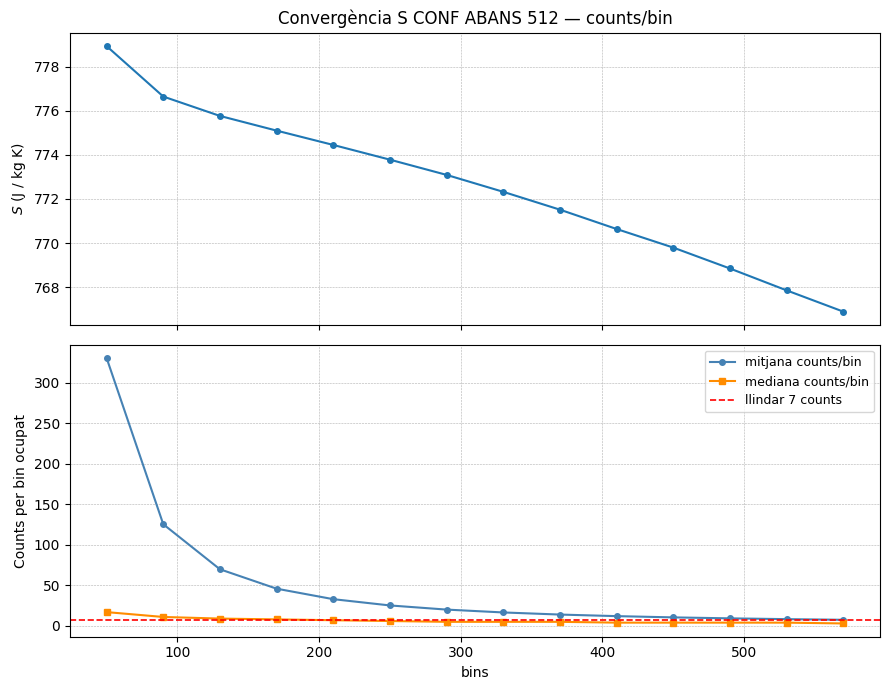

[330.74935401 125.49019608  69.88806989  45.9316408   32.97057119
  25.23659306  20.10444889  16.58460741  13.97456193  12.04082593
  10.49158829   9.29725804   8.31560312   7.50062261] [17. 11.  9.  8.  7.  6.  5.  5.  5.  4.  4.  4.  4.  3.]


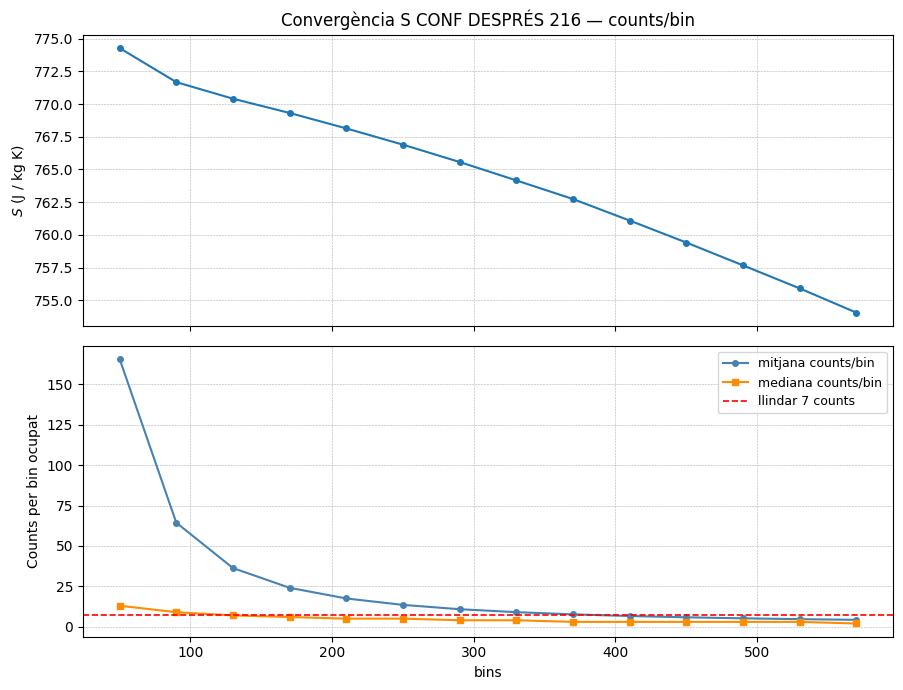

626.5085691560581 777.1885765207478 150.6800073646897
627.3069569296099 772.3706757397969 145.06371881018697


In [ ]:
P = 1

S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    nou_despres(P), entropy_fn=entropy_conf,
    bins_list=np.arange(50, 601, 40),
    threshold=7,
    label="Convergència S CONF DESPRÉS 512 — counts/bin"
)
print(mean_c, median_c)
S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    antic_despres(P), entropy_fn=entropy_conf,
    bins_list=np.arange(50, 601, 40),
    threshold=7,
    label="Convergència S CONF DESPRÉS 216 — counts/bin"
)
S512a = entropy_conf(nou_abans(P), 75)[0]
S512b = entropy_conf(nou_despres(P), 75)[0]
print(S512a, S512b, S512b - S512a)
S512a = entropy_conf(antic_abans(P), 75)[0]
S512b = entropy_conf(antic_despres(P), 75)[0]
print(S512a, S512b, S512b - S512a)

# Prova amb theta, phi

In [ ]:
#Stot, Sthphi, Sthpsi, Sphipsi, Sth, Sphi, Spsi
llp = [   1, 1000, 2000, 3000, 4000]
for P in llp:
    print(f"P={P} bar")
    n = 1
    bins = 100
    S512a = entropy_ori_nou_plot(nou_abans(P), 50)[n]
    S512b = entropy_ori_nou_plot(nou_despres(P), 50)[n]
    print(S512a, S512b, S512b - S512a)
    S512a = entropy_ori_nou_plot(antic_abans(P), 50)[n]
    S512b = entropy_ori_nou_plot(antic_despres(P), 50)[n]
    print(S512a, S512b, S512b - S512a)

N punts: 512000


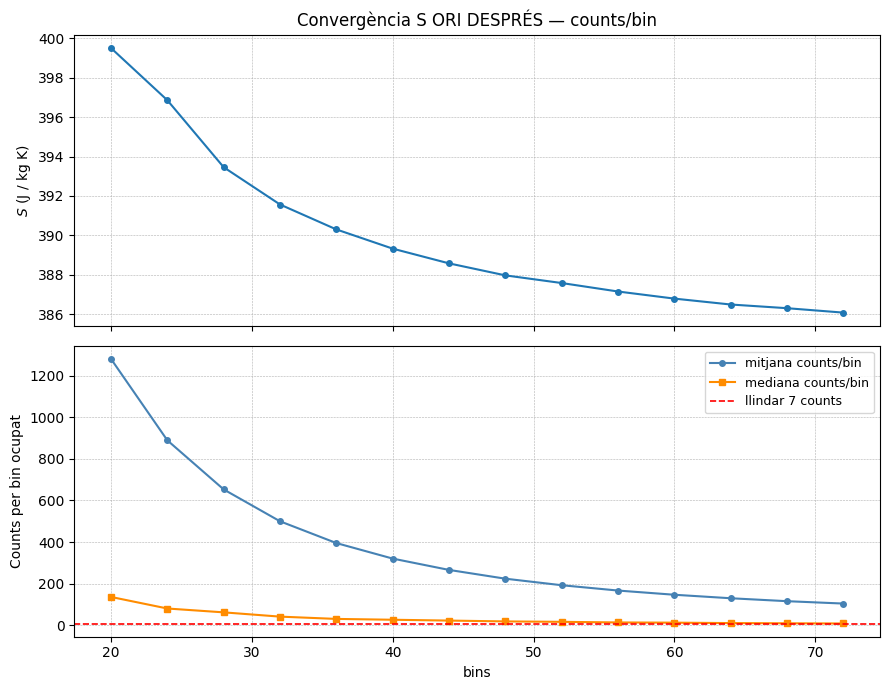

N punts: 216000


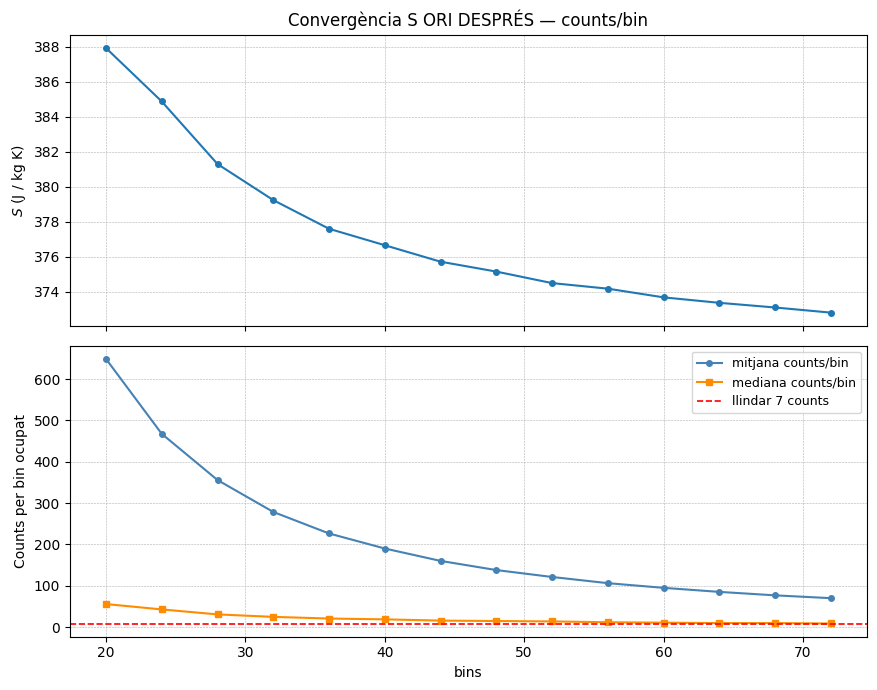

In [473]:
def entropy_thephi(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[8]))
                phi.append(float(cols[9]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    edges1 = np.linspace(-1, 1, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges1, edges], density=True)
    Ap = 360 / bins
    Ap1 = 2 / bins
    p  = hist * Ap * Ap1
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap1)
    return S / massa, p
P =3000
S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    nou_abans(P), entropy_fn=entropy_thephi,
    bins_list=np.arange(20, 76, 4),
    threshold=7,
    label="Convergència S ORI DESPRÉS — counts/bin"
)

S_list, mean_c, median_c, pct_below = convergence_plot_counts(
    antic_abans(P), entropy_fn=entropy_thephi,
    bins_list=np.arange(20, 76, 4),
    threshold=7,
    label="Convergència S ORI DESPRÉS — counts/bin"
)

# Límit en p

  llegit /home/aressanuy/Desktop/doc/NPG/entropianou/nou/ang_ori_300_1_2.dat  →  T = 300.0 K,  512000 punts
  llegit /home/aressanuy/Desktop/doc/NPG/entropianou/nou/ang_ori_305_1_2.dat  →  T = 305.0 K,  512000 punts
  p_thresh=0e+00  →  S = [np.float64(648.4561174682555), np.float64(983.2719585675501)]
  p_thresh=1e-05  →  S = [np.float64(645.9464514066046), np.float64(983.2269884136168)]
  p_thresh=3e-05  →  S = [np.float64(643.4391893420095), np.float64(979.3681854140804)]
  p_thresh=5e-05  →  S = [np.float64(641.380695940009), np.float64(963.3720234551314)]
  p_thresh=6e-05  →  S = [np.float64(640.5087967431489), np.float64(945.9666651307572)]
  p_thresh=7e-05  →  S = [np.float64(639.5601060734067), np.float64(921.5633243369633)]
  p_thresh=8e-05  →  S = [np.float64(638.8304331497667), np.float64(887.9851339115427)]
  p_thresh=9e-05  →  S = [np.float64(637.6284854594934), np.float64(841.4884912661608)]
  p_thresh=1e-04  →  S = [np.float64(636.9279002931679), np.float64(797.237698929

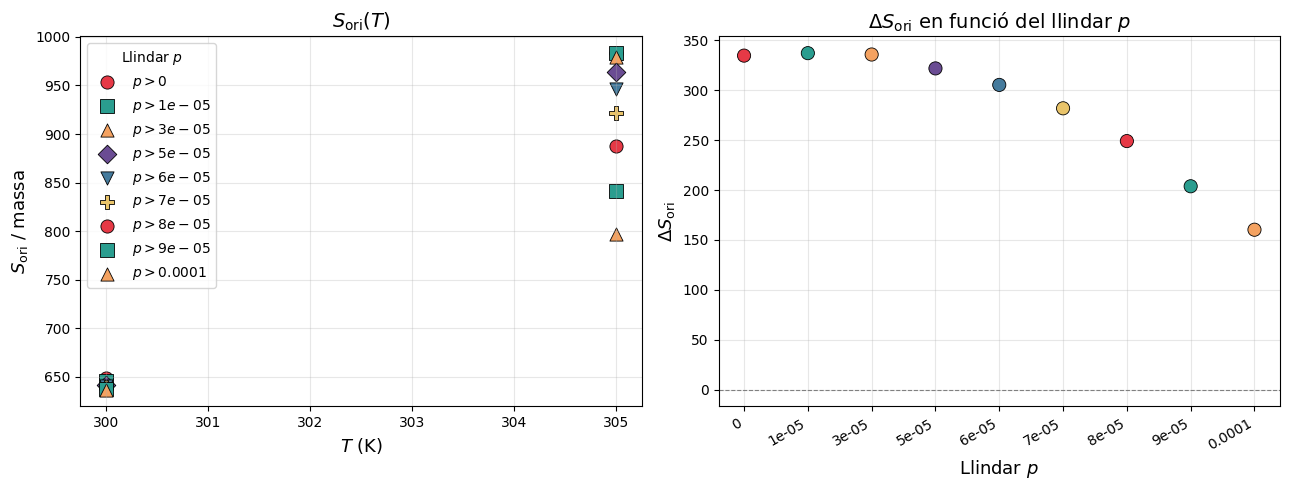

In [54]:

# Llista de fitxers ordenats per temperatura creixent
FILES = [
    nou_abans(1),
    nou_despres(1),
]

# Llindar de p a estudiar
P_THRESHOLDS = [0,0.00001,0.00003,0.00005,0.00006,0.00007,0.00008,0.00009,0.0001]

BINS  = 20
MASSA = massa

# ───────────────────────────────────────────────────────────────────────────────


def extract_temperature(fname):
    match = re.search(r'ang_ori_(\d+)_', fname)
    if match:
        return float(match.group(1))
    return None


def read_angles(fname):
    """Llegeix columnes th (col 8), phi (col 9), psi (col 10)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue
    return np.array(th), np.array(phi), np.array(psi)


def entropy_with_pthresh(th, phi, psi, p_thresh, bins=100):
    """Calcula S aplicant el llindar p > p_thresh."""
    intervals = [
        np.linspace(-1,    1,   bins + 1),
        np.linspace(-180, 180,  bins + 1),
        np.linspace(-180, 180,  bins + 1),
    ]
    hist, edges = np.histogramdd((th, phi, psi), bins=intervals)

    # Normalització → p suma 1
    p = hist / hist.sum()

    # Correcció d'àrea
    dth  = edges[0][1] - edges[0][0]
    dphi = edges[1][1] - edges[1][0]
    dpsi = edges[2][1] - edges[2][0]
    A = dth * dphi * dpsi

    # Màscara amb llindar
    mask = p > p_thresh
    S = -k * np.sum(p[mask] * np.log(p[mask])) + k * np.log(A)
    return S / MASSA


def main():
    # ── 1. Llegir dades i temperatures ─────────────────────────────────────────
    temps, angle_data = [], []
    for fname in FILES:
        T = extract_temperature(fname)
        temps.append(T)
        th, phi, psi = read_angles(fname)
        angle_data.append((th, phi, psi))
        print(f"  llegit {fname}  →  T = {T} K,  {len(th)} punts")
 
    temps = np.array(temps)
    sort_idx = np.argsort(temps)
    temps      = temps[sort_idx]
    angle_data = [angle_data[i] for i in sort_idx]
 
    # ── 2. Calcular S per a cada p_thresh ──────────────────────────────────────
    results = {}   # {p_thresh: [S(T1), S(T2), ...]}
    for p_thresh in P_THRESHOLDS:
        S_vals = []
        for th, phi, psi in angle_data:
            S = entropy_with_pthresh(th, phi, psi, p_thresh, bins=BINS)
            S_vals.append(S)
        results[p_thresh] = np.array(S_vals)
        print(f"  p_thresh={p_thresh:.0e}  →  S = {S_vals}")
 
    # ── 3. Gràfica S(T) i ΔS ──────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
 
    base_colors  = ['#e63946', '#2a9d8f', '#f4a261', '#6a4c93', '#457b9d', '#e9c46a']
    base_markers = ['o', 's', '^', 'D', 'v', 'P']

    n = len(P_THRESHOLDS)
    colors  = [base_colors[i % len(base_colors)]   for i in range(n)]
    markers = [base_markers[i % len(base_markers)] for i in range(n)]
 
    for (p_thresh, S_vals), color, marker in zip(results.items(), colors, markers):
        label = f"$p > {p_thresh}$"
        kw = dict(s=90, label=label, color=color, marker=marker,
                  edgecolors='black', linewidths=0.6)

        # Esquerra: S absoluta per cada fitxer
        ax1.scatter(temps, S_vals, **kw)

    ax1.set_xlabel("$T$ (K)", fontsize=13)
    ax1.set_ylabel("$S_{\\mathrm{ori}}$ / massa", fontsize=13)
    ax1.set_title("$S_{\\mathrm{ori}}(T)$", fontsize=14)
    ax1.legend(title="Llindar $p$", fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Dreta: ΔS(file2 - file1) per a cada p_thresh
    delta_S_per_p = [S_vals[1] - S_vals[0] for S_vals in results.values()]
    p_thresholds  = list(results.keys())

    ax2.scatter(range(len(p_thresholds)), delta_S_per_p,
                s=90, c=colors[:len(p_thresholds)],
                edgecolors='black', linewidths=0.6, zorder=3)
    ax2.set_xticks(range(len(p_thresholds)))
    ax2.set_xticklabels([str(p) for p in p_thresholds], rotation=30, ha='right')
    ax2.set_xlabel("Llindar $p$", fontsize=13)
    ax2.set_ylabel("$\\Delta S_{\\mathrm{ori}}$", fontsize=13)
    ax2.set_title("$\\Delta S_{\\mathrm{ori}}$ en funció del llindar $p$", fontsize=14)
    ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax2.grid(True, alpha=0.3)
 
    fig.tight_layout()
 
    out_png = "entropy_vs_T_pthresh.png"
    #fig.savefig(out_png, dpi=150)
    print(f"\nGràfica guardada a: {out_png}")
    plt.show()
 


if __name__ == "__main__":
    main()
  



# Errors 

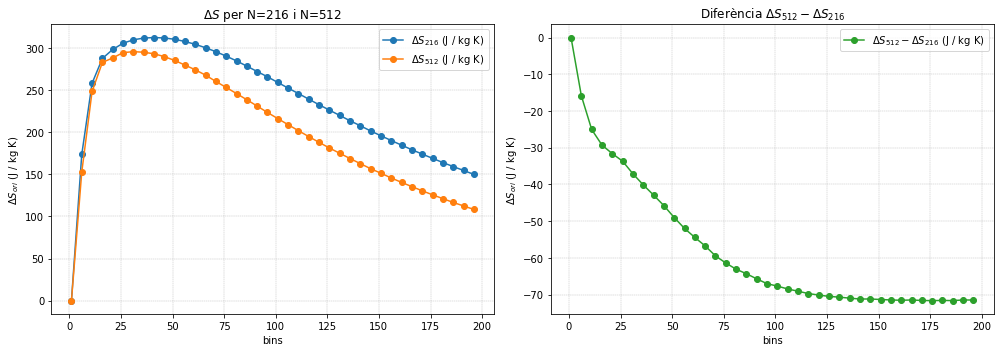

(703.2262722179923, 594.993128456429)

In [17]:
def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             file_512_a, file_512_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216, S512 = [], []
    llS512a,llS512b = [], []
    diff = []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]   
        S216.append(S216a - S216b)
        S512a = entropy_fn(file_512_a, bins=b)[0]
        llS512a.append(S512a)
        S512b = entropy_fn(file_512_b, bins=b)[0]
        llS512b.append(S512b)
        S512.append(S512a - S512b)
        diff.append(S512a - S216a)


    S216, S512 = np.array(S216), np.array(S512)


    #for b, s216, s512 in zip(bins_list, S216, S512):
    #    print(f"bins={b:3d}  S216={s216:.6e}  S512={s512:.6e} ")
    #    print(f"{S216b} ")
    #    print(f"{S216a} ")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Esquerra: S216 i S512 ---
    axes[0].plot(bins_list, S216, '-o', label=r'$\Delta S_{216}$ (J / kg K)')
    axes[0].plot(bins_list, S512, '-o', label=r'$\Delta S_{512}$ (J / kg K)')
    axes[0].set_xlabel('bins')
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    axes[0].grid(True, ls='--', lw=0.4)
    axes[0].set_title(r'$\Delta S$ per N=216 i N=512')

    # --- Dreta: diff ---
    axes[1].plot(bins_list, diff, '-o', color='tab:green', label=r'$\Delta S_{512} - \Delta S_{216}$ (J / kg K)')
    axes[1].set_xlabel('bins')
    axes[1].set_ylabel(ylabel)
    axes[1].legend()
    axes[1].grid(True, ls='--', lw=0.4)
    axes[1].set_title(r'Diferència $\Delta S_{512} - \Delta S_{216}$')

    plt.tight_layout()
    plt.show()

    return S512a, S512b


bins_list = np.arange(1, 200, 5)
#bins_list = np.arange(350, 351, 100)

P = 2000
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)
file_512_b = antic_abans(P)
file_512_a = antic_despres(P)


# Amb entropy_conf 
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_ori, ylabel=r'$\Delta S_{ori}$ (J / kg K)')

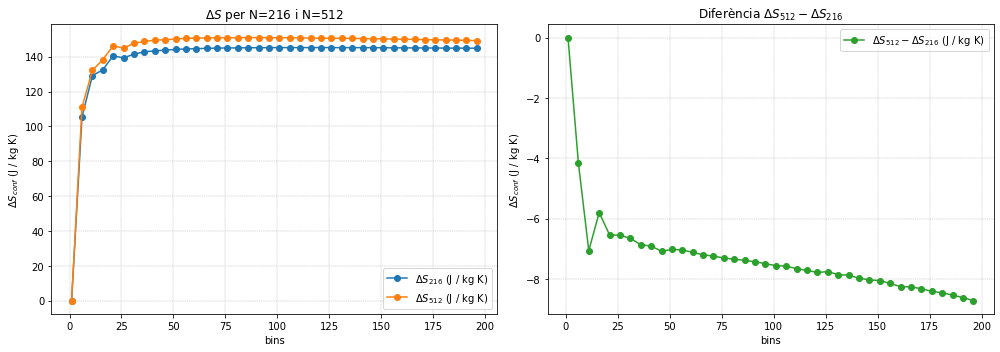

(775.1776583808004, 625.9228891508134)

In [18]:
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, file_512_a, file_512_b, entropy_fn=entropy_conf, ylabel=r'$\Delta S_{conf}$ (J / kg K)')